In [33]:
import numpy as np
import obspy
import emd
import pandas as pd
from tqdm.notebook import tqdm
import os
import scipy.signal as sg
from concurrent.futures import ThreadPoolExecutor
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import clear_output
from torchinfo import summary
import librosa
import pywt
from scipy.stats import entropy
import nolds
from sklearn.preprocessing import StandardScaler

<h1>DISEÑO DE LOS FILTROS<h1>

In [2]:
# Función de filtro pasa-banda utilizando el diseño de filtro Butterworth.
# Filtra los datos entre las frecuencias lowc y high.
def butter_bandpass_filter(senal: np.array, lowcut: float, highcut: float, fs: float, order: int):
    nyquist = 0.5 * fs  # Frecuencia de Nyquist, la mitad de la tasa de muestreo
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = sg.butter(order, [low, high], btype='band', analog=False)  # Diseña el filtro pasa-banda Butterworth
    y = sg.filtfilt(b, a, senal)  # Aplica el filtro a los datos usando filtrado cero-fase
    return y

In [3]:
def notch_filter(senal, fs, f0, Q):
    """
    senal : array-like
        La señal de entrada a la que se le aplicará el filtro.
    fs : float
        Frecuencia de muestreo de la señal (en Hz).
    f0 : float
        Frecuencia central que se desea eliminar (en Hz).
    Q : float
        Factor de calidad del filtro notch.
    """
    # Diseñar el filtro notch
    b, a = sg.iirnotch(f0, Q, fs)

    # Aplicar el filtro a la señal
    senal_filtrada = sg.lfilter(b, a, senal)

    return senal_filtrada

In [4]:
# Ruta de la carpeta donde están los archivos de audio
folder_path = "./Respiratory_Sound_Database\Respiratory_Sound_Database//audio_and_txt_files"
# Obtener lista de archivos de audio en la carpeta
audio_files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]

audio_path = os.path.join(folder_path, audio_files[7])

In [5]:
audio_files[7]

'104_1b1_Lr_sc_Litt3200.wav'

In [6]:
#DATOS ORIGINALES 

audio, sr = librosa.load(audio_path, sr=None)  # sr=None para mantener la tasa de muestreo original
time = np.arange(len(audio))/sr

In [7]:
sr

4000

In [8]:
#DATOS CON FILTRO PASABANDA
"""Las señales de respiración humana suelen contener información útil en el rango de 100 Hz a 2000 Hz.

Frecuencias bajas (100 Hz): Las respiraciones normales tienen componentes de baja frecuencia que representan el flujo de aire en los pulmones.

Frecuencias altas (2000 Hz): Algunos sonidos respiratorios, como sibilancias o crepitaciones, pueden tener componentes de mayor frecuencia.

Las frecuencias fuera de este rango suelen ser ruido no deseado:

Ruido de baja frecuencia (<100 Hz): Puede ser causado por movimientos del cuerpo, vibraciones o interferencias.

Ruido de alta frecuencia (>2000 Hz): Puede ser causado por ruido ambiental, como el zumbido de equipos eléctricos. """

audiof1 = butter_bandpass_filter(audio, 100, 1800, sr, 4)

In [9]:
#DATOS CON FILTRO NOTCH
"""50 Hz: Es la frecuencia de la red eléctrica en Portugal y Grecia (los países donde se creó la base de datos)."""
audiof2 = notch_filter(audiof1, sr, 50, 35)

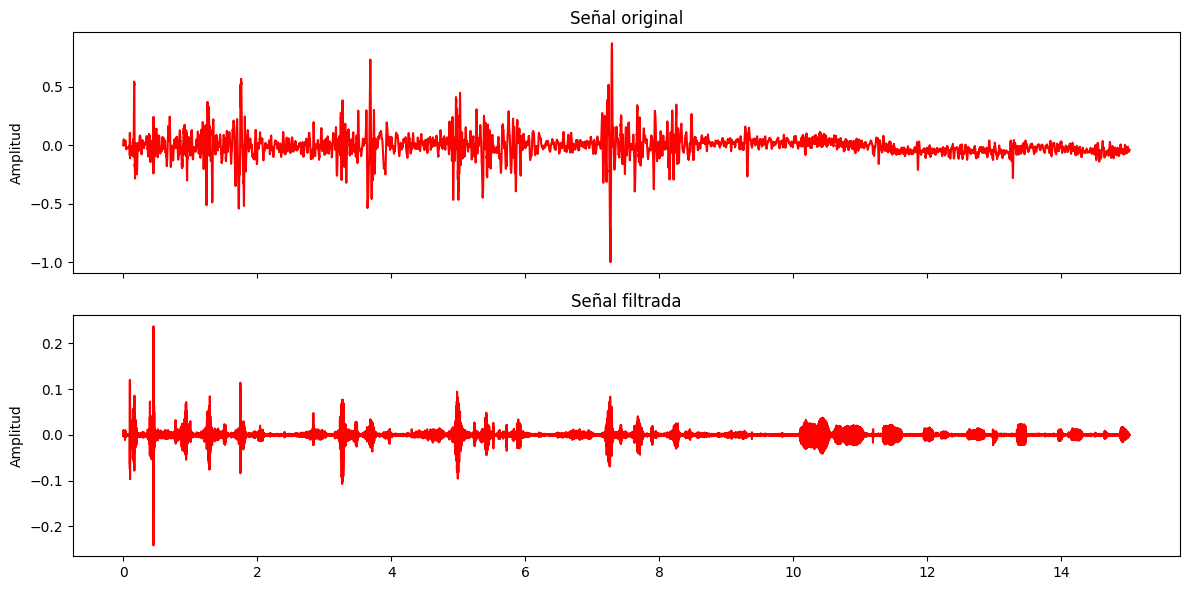

In [10]:
# Graficar las formas de onda
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Gráfico de señal original
ax[0].plot(time, audio, color='red')
ax[0].set_title("Señal original")
ax[0].set_ylabel("Amplitud")

# Gráfico de señal después de los filtros
ax[1].plot(time, audiof2, color='red')
ax[1].set_title("Señal filtrada")
ax[1].set_ylabel("Amplitud")


plt.tight_layout()  
plt.show()

<h1>EXTRACCIÓN DE CARACTERÍSTICAS<h1>

c:\Users\jhose\anaconda3\envs\data\lib\site-packages\librosa\feature\spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


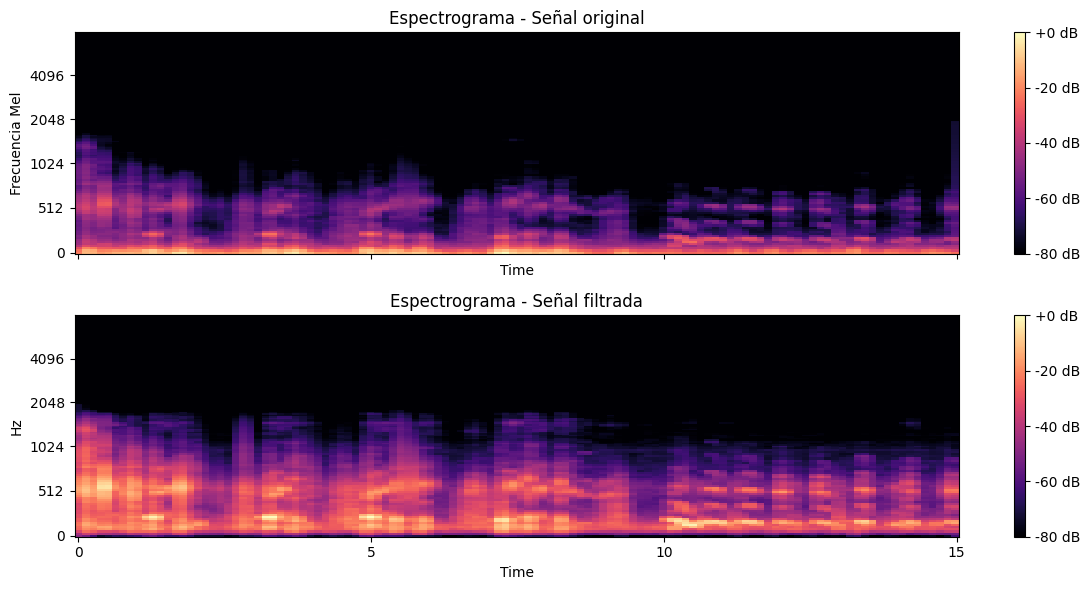

In [11]:
# Convertir a espectrograma de Mel
n_mels = 128  # Número de filtros de Mel

# Calcular espectrogramas
D = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, fmax=8000)  # Filtrado hasta 8 kHz
Df = librosa.feature.melspectrogram(y=audiof2, sr=sr, n_mels=n_mels, fmax=8000)  # Filtrado hasta 8 kHz


# Convertir a escala logarítmica (más similar a cómo escucha el oído humano)
D_dB = librosa.power_to_db(D, ref=np.max)
Df_dB = librosa.power_to_db(Df, ref=np.max)


# Crear la figura con dos subgráficos
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Graficar el espectrograma de Mel de señal original
librosa.display.specshow(D_dB, sr=sr, x_axis="time", y_axis="mel", fmax=8000, ax = ax[0])
ax[0].set_title("Espectrograma - Señal original")
ax[0].set_ylabel("Frecuencia Mel")
fig.colorbar(librosa.display.specshow(D_dB, sr=sr, x_axis="time", y_axis="mel", fmax=8000), ax = ax[0], format="%+2.0f dB")

# Graficar el espectrograma de Mel de señal filtrada
librosa.display.specshow(Df_dB, sr=sr, x_axis="time", y_axis="mel", fmax=8000, ax = ax[1])
ax[1].set_title("Espectrograma - Señal filtrada")
ax[1].set_ylabel("Frecuencia Mel")
fig.colorbar(librosa.display.specshow(Df_dB, sr=sr, x_axis="time", y_axis="mel", fmax=8000), ax = ax[1], format="%+2.0f dB")

plt.tight_layout()  
plt.show()

In [12]:
# Extraer MFCCs 

def extraer_caracteristicas_mfccs(audio, frecuencia, numero):
    mfccs = librosa.feature.mfcc(y=audio, sr=frecuencia, n_mfcc=numero)  #n:mfcc a evaluar según rendimiento del modelo

    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_std = np.std(mfccs, axis=1)
    mfccs_max = np.max(mfccs, axis=1)
    mfccs_min = np.min(mfccs, axis=1)


    # Concatenar estadísticas de MFCCs
    caracteristicas_mfcc = np.concatenate([mfccs_mean, mfccs_std, mfccs_max, mfccs_min])
    return caracteristicas_mfcc

caracteristicas_mfcc = extraer_caracteristicas_mfccs(audiof2, sr, 10)

In [13]:
caracteristicas_mfcc

array([-499.67955243,  181.51544646,   -9.1150378 ,  -29.3187117 ,
        -15.2041548 ,    5.77757086,   -9.29162297,  -12.02708139,
        -32.38831455,  -35.88408588,   83.33663223,   22.43505103,
         33.44955887,   16.36651983,   14.83936186,   14.60741771,
          8.65370425,    7.52446301,    8.23550675,    6.4723233 ,
       -237.75102745,  228.35252139,   37.08382522,   19.30595695,
          8.95740831,   42.24353499,   12.23680414,   15.52540088,
        -17.56355808,  -10.77837909, -620.87276058,  118.61778193,
       -114.0960596 ,  -62.69808982,  -58.20374474,  -23.73673494,
        -30.46100796,  -35.17534863,  -56.8038861 ,  -49.3318972 ])

In [14]:
# Función para extraer características wavelet
def extraer_caracteristicas_wavelet(senal, wavelet='db4', nivel=5):
    coeficientes = pywt.wavedec(senal, wavelet, level=nivel)
    caracteristicas_wavelet = []
    for coef in coeficientes:
        caracteristicas_wavelet.append(np.mean(coef))  # Media
        caracteristicas_wavelet.append(np.std(coef))   # Desviación estándar
        caracteristicas_wavelet.append(np.max(coef))   # Máximo
        caracteristicas_wavelet.append(np.min(coef))   # Mínimo
    return np.array(caracteristicas_wavelet)

# Extraer características wavelet
caracteristicas_wavelet = extraer_caracteristicas_wavelet(audiof2)

In [31]:
len(audiof2)

60096

In [15]:
caracteristicas_wavelet

array([ 4.56150644e-05,  2.57887840e-03,  1.86748907e-02, -1.60936779e-02,
       -4.95996371e-04,  1.60572262e-02,  1.17516761e-01, -1.12565160e-01,
        2.54805350e-04,  2.50536997e-02,  2.81402414e-01, -2.84758669e-01,
        8.81484228e-06,  1.16005094e-02,  1.57578933e-01, -2.08331444e-01,
       -1.58473704e-05,  7.49459452e-03,  3.45284007e-01, -3.97476292e-01,
        1.49317608e-08,  1.15065757e-03,  5.57277060e-02, -5.13413925e-02])

In [16]:
# Función para calcular la entropía de Shannon
def calcular_entropia(senal):
    hist, _ = np.histogram(senal, bins=50, density=True)
    hist = hist / np.sum(hist)
    return entropy(hist)

# Calcular características de complejidad
entropia_shannon = calcular_entropia(audiof2)
dimension_fractal = nolds.hurst_rs(audiof2)
variabilidad = np.std(np.diff(audiof2))

# Combinar todas las características
caracteristicas = np.concatenate([caracteristicas_mfcc, caracteristicas_wavelet, [entropia_shannon, dimension_fractal, variabilidad]])

print("Número total de características:", len(caracteristicas))
print("Características combinadas:", caracteristicas)

Número total de características: 67
Características combinadas: [-4.99679552e+02  1.81515446e+02 -9.11503780e+00 -2.93187117e+01
 -1.52041548e+01  5.77757086e+00 -9.29162297e+00 -1.20270814e+01
 -3.23883146e+01 -3.58840859e+01  8.33366322e+01  2.24350510e+01
  3.34495589e+01  1.63665198e+01  1.48393619e+01  1.46074177e+01
  8.65370425e+00  7.52446301e+00  8.23550675e+00  6.47232330e+00
 -2.37751027e+02  2.28352521e+02  3.70838252e+01  1.93059569e+01
  8.95740831e+00  4.22435350e+01  1.22368041e+01  1.55254009e+01
 -1.75635581e+01 -1.07783791e+01 -6.20872761e+02  1.18617782e+02
 -1.14096060e+02 -6.26980898e+01 -5.82037447e+01 -2.37367349e+01
 -3.04610080e+01 -3.51753486e+01 -5.68038861e+01 -4.93318972e+01
  4.56150644e-05  2.57887840e-03  1.86748907e-02 -1.60936779e-02
 -4.95996371e-04  1.60572262e-02  1.17516761e-01 -1.12565160e-01
  2.54805350e-04  2.50536997e-02  2.81402414e-01 -2.84758669e-01
  8.81484228e-06  1.16005094e-02  1.57578933e-01 -2.08331444e-01
 -1.58473704e-05  7.494594

In [37]:
caracteristicas

array([-4.99679552e+02,  1.81515446e+02, -9.11503780e+00, -2.93187117e+01,
       -1.52041548e+01,  5.77757086e+00, -9.29162297e+00, -1.20270814e+01,
       -3.23883146e+01, -3.58840859e+01,  8.33366322e+01,  2.24350510e+01,
        3.34495589e+01,  1.63665198e+01,  1.48393619e+01,  1.46074177e+01,
        8.65370425e+00,  7.52446301e+00,  8.23550675e+00,  6.47232330e+00,
       -2.37751027e+02,  2.28352521e+02,  3.70838252e+01,  1.93059569e+01,
        8.95740831e+00,  4.22435350e+01,  1.22368041e+01,  1.55254009e+01,
       -1.75635581e+01, -1.07783791e+01, -6.20872761e+02,  1.18617782e+02,
       -1.14096060e+02, -6.26980898e+01, -5.82037447e+01, -2.37367349e+01,
       -3.04610080e+01, -3.51753486e+01, -5.68038861e+01, -4.93318972e+01,
        4.56150644e-05,  2.57887840e-03,  1.86748907e-02, -1.60936779e-02,
       -4.95996371e-04,  1.60572262e-02,  1.17516761e-01, -1.12565160e-01,
        2.54805350e-04,  2.50536997e-02,  2.81402414e-01, -2.84758669e-01,
        8.81484228e-06,  

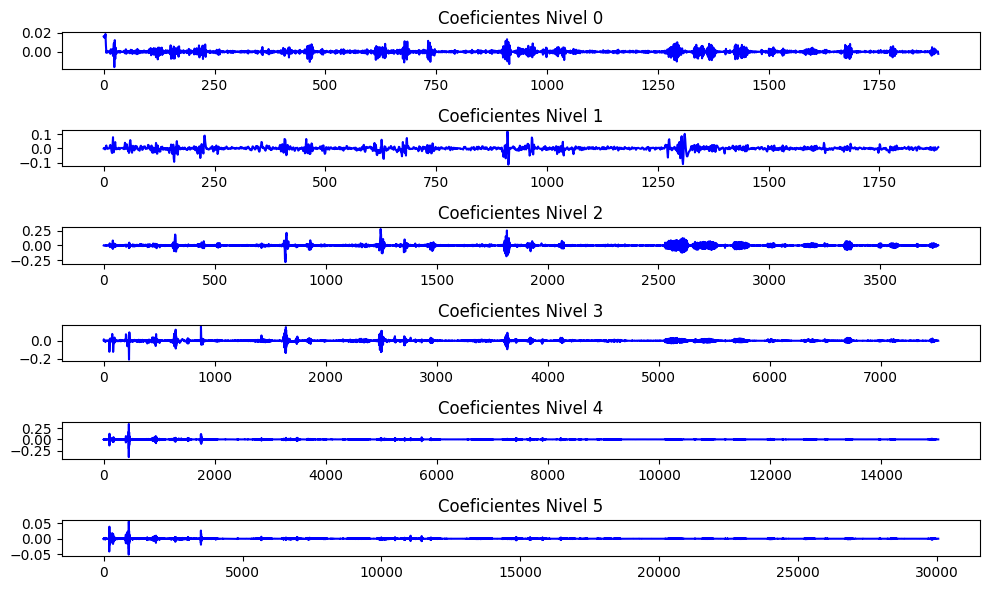

In [17]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# Función para extraer y visualizar coeficientes wavelet
def visualizar_wavelet(senal, wavelet='db4', nivel=5):
    coeficientes = pywt.wavedec(senal, wavelet, level=nivel)

    # Definir el número real de niveles obtenidos
    niveles_reales = len(coeficientes)

    # Crear subgráficos ajustados al número de coeficientes
    fig, axes = plt.subplots(niveles_reales, 1, figsize=(10, 6))

    # Si solo hay un nivel, matplotlib devuelve un solo objeto en vez de una lista, lo convertimos en lista
    if niveles_reales == 1:
        axes = [axes]

    # Graficar los coeficientes en cada nivel
    for i, coef in enumerate(coeficientes):
        axes[i].plot(coef, color='blue')
        axes[i].set_title(f"Coeficientes Nivel {i}")

    plt.tight_layout()
    plt.show()

# Llamar a la función con tu señal
visualizar_wavelet(audiof2)


<p>Esto no va</p>

In [18]:
N = len(audiof2)
print(f"Número de muestras en la señal: {N}")


Número de muestras en la señal: 60096


In [19]:
import numpy as np
import pywt

def determinar_nivel_maximo(senal, wavelet='db4', umbral=0.0001):
    niveles_max = int(np.log2(len(senal)))  # Nivel máximo teórico
    coeficientes = pywt.wavedec(senal, wavelet, level=niveles_max)
    
    energias = [np.sum(np.abs(c)**2) for c in coeficientes]  # Energía en cada nivel
    energia_total = sum(energias)
    print(energias)

    for i, energia in enumerate(energias):
        if energia / energia_total < umbral:  # Si cae por debajo del umbral
            return i  # Devuelve el nivel antes de perder información útil
    
    return niveles_max  # Si todos los niveles tienen energía significativa, usa el máximo

nivel_optimo = determinar_nivel_maximo(audiof2)
print(f"Nivel óptimo de descomposición: {nivel_optimo}")


[1.1601264684767383, 0.011449032400289693, 0.00579144554664087, 0.0029779461062282454, 0.0015057178999441094, 0.000780331219162276, 0.0003925193150178369, 0.00020722165089081724, 0.0001244035875557973, 0.0007156425649343251, 0.010507871380623186, 0.4862237130932211, 2.361606005626873, 1.011711511330563, 0.8441668791451669, 0.03978790974792017]
Nivel óptimo de descomposición: 6


c:\Users\jhose\anaconda3\envs\data\lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 15 is too high: all coefficients will experience boundary effects.
  warnings.warn(


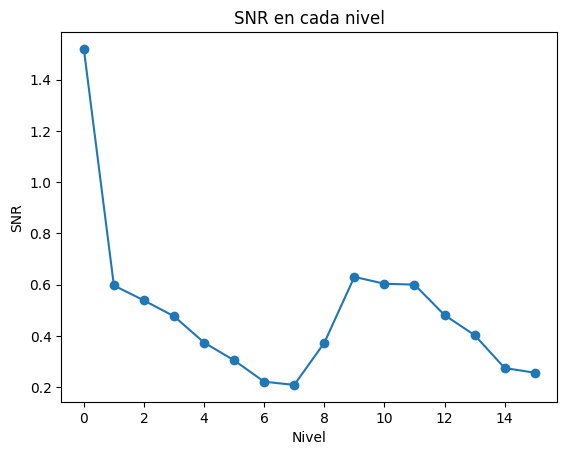

In [20]:
niveles_max = int(np.log2(len(audiof2)))  # Nivel máximo teórico
coeficientes = pywt.wavedec(audiof2, "db4", level=niveles_max)


snr_niveles = [np.mean(np.abs(c)) / np.std(c) for c in coeficientes]
plt.plot(snr_niveles, marker='o')
plt.title("SNR en cada nivel")
plt.xlabel("Nivel")
plt.ylabel("SNR")
plt.show()


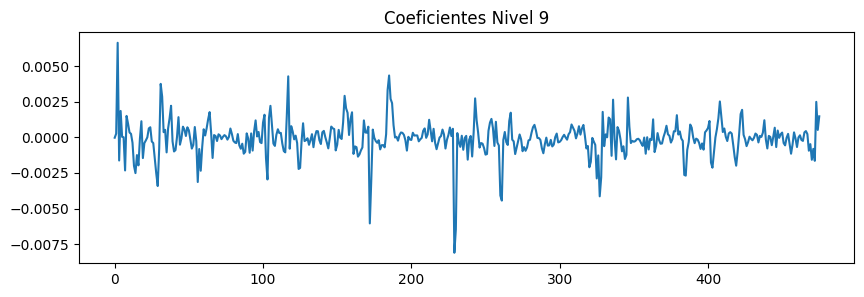

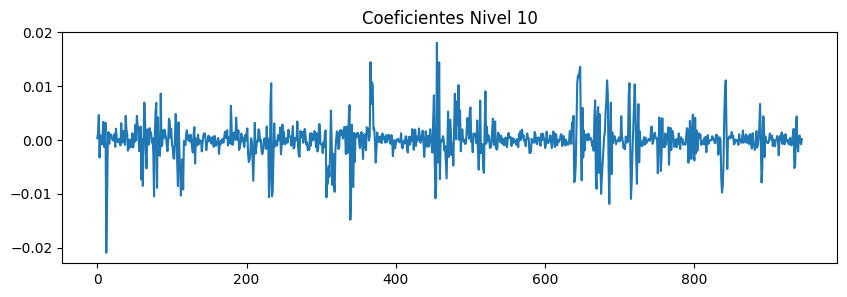

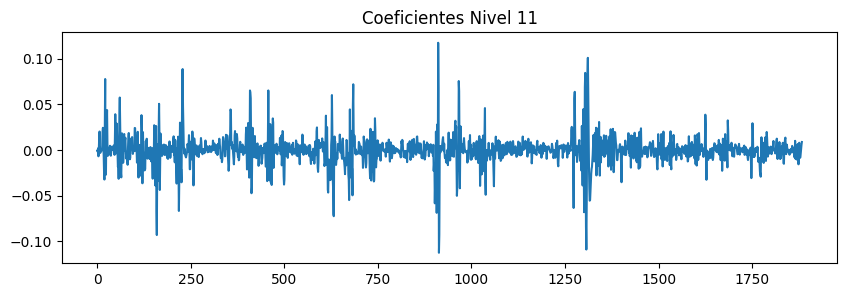

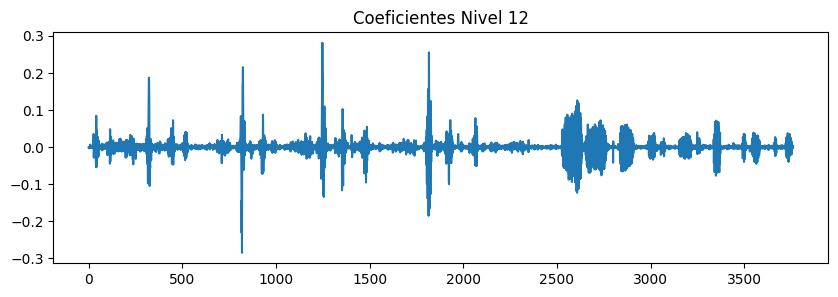

In [21]:
for i in range(9, 13):  # Niveles 9 a 12
    plt.figure(figsize=(10, 3))
    plt.plot(coeficientes[i])
    plt.title(f"Coeficientes Nivel {i}")
    plt.show()


In [22]:
import numpy as np
import pywt

def wavelet_snr_thresholding(signal, wavelet='db4', level=15, snr_threshold=10):
    # Aplicar la transformada wavelet
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    
    # Estimar el ruido a partir de los coeficientes de la escala más fina
    noise_std = np.mean(np.abs(coeffs[-1])) / 0.6745  # Estimación robusta del ruido
    E_noise = noise_std**2  # Energía del ruido
    print(E_noise)
    # Seleccionar coeficientes basados en la SNR
    selected_coeffs = []
    for i, c in enumerate(coeffs):
        E_coeff = np.sum(c**2)  # Energía del coeficiente
        snr = 10 * np.log10(E_coeff / E_noise)  # SNR en dB
        print(E_coeff)
        if snr > snr_threshold:
            selected_coeffs.append(c)  # Conservar el coeficiente
            #print(snr, i)
        else:
            selected_coeffs.append(np.zeros_like(c))  # Descartar el coeficiente
    
    return selected_coeffs

# Ejemplo de uso

selected_coeffs = wavelet_snr_thresholding(audiof2, wavelet='db4', level=15, snr_threshold=10)

# Reconstruir la señal (opcional)
filtered_signal = pywt.waverec(selected_coeffs, 'db4')

1.9112302607538085e-07
1.1601264684767383
0.011449032400289693
0.00579144554664087
0.0029779461062282454
0.0015057178999441094
0.000780331219162276
0.0003925193150178369
0.00020722165089081724
0.0001244035875557973
0.0007156425649343251
0.010507871380623186
0.4862237130932211
2.361606005626873
1.011711511330563
0.8441668791451669
0.03978790974792017


In [23]:
selected_coeffs

[array([ 0.45214877,  0.46708434,  0.46139935,  0.44319939,  0.54307759,
         0.18175315,  0.00224853, -0.01525052]),
 array([-0.00180721, -0.00035519,  0.09644724, -0.03808626,  0.02438942,
        -0.00912466, -0.00123105,  0.00365906]),
 array([-0.00129011, -0.00025303,  0.06884874, -0.02715533,  0.01599684,
        -0.00646553, -0.00251286,  0.00084466,  0.00263072, -0.00071098]),
 array([-9.20163007e-04, -1.78042503e-04,  4.91492035e-02, -1.93897424e-02,
         1.14239480e-02, -4.27506836e-03,  9.46667850e-07, -2.02151900e-07,
        -1.12741884e-05,  2.36187400e-04, -3.45327088e-03,  4.63119391e-03,
        -1.76501912e-03,  3.66547692e-04]),
 array([-6.58127596e-04, -1.31132191e-04,  3.50848538e-02, -1.38481889e-02,
         8.15528926e-03, -3.05373466e-03,  5.60943334e-07, -9.36445572e-08,
        -1.23564845e-06, -2.61242660e-06, -2.21287655e-07, -2.78904691e-07,
        -3.38074318e-06, -7.04526846e-09, -3.65123786e-07, -2.55784013e-06,
        -3.21717636e-04, -1.6993

In [38]:
def extract_respiratory_features(audio, sr):
    """Extrae todas las características relevantes para respiración."""
    # 1. Características temporales
    rms_energy = librosa.feature.rms(y=audio)[0]
    zcr = librosa.feature.zero_crossing_rate(audio)[0]
    
    # 2. Características espectrales
    S = np.abs(librosa.stft(audio))
    spectral_rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)[0]
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=10)  # 13 MFCCs estándar
    
    # 3. Características wavelet
    wavelet_features = extraer_caracteristicas_wavelet(audio)
    
    # 4. Características no lineales
    hurst = nolds.hurst_rs(audio)
    shannon_entropy = nolds.sampen(audio)  # Entropía muestral
    
    # Combinar todas las características
    return np.concatenate([
        np.mean(mfccs, axis=1),
        [np.mean(rms_energy)],
        [np.mean(zcr)],
        [np.mean(spectral_rolloff)],
        wavelet_features,
        [hurst, shannon_entropy]
    ])


In [39]:
extract_respiratory_features(audiof2, sr)

KeyboardInterrupt: 